## 1. Setup & Load Data from S3
Loads the raw Grad Café JSON from S3 into a DataFrame using boto3.

In [1]:
!pip install --quiet scipy matplotlib pandas numpy reportlab



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
"""Load the full course-provided dataset from local file"""
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 110

RAW_FILE = "llm_extend_applicant_data_run.jsonl"

records = []
with open(RAW_FILE, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

raw = pd.DataFrame(records)
raw = raw.drop(columns=["program"], errors="ignore")

# The course-provided file uses different column names than the original
# scraper output this notebook was originally built around. Renaming here
# lets the rest of the notebook run unchanged.
column_rename = {
    "university_raw": "university",
    "program_raw": "program",
    "date_added": "date",
    "Degree": "degree_type",
    "US/International": "international",
    "GPA": "gpa",
    "GRE": "gre",
    "GRE V": "gre_v",
    "GRE AW": "gre_aw",
}
df = raw.rename(columns=column_rename)

print(f"Loaded {len(df)} rows from {RAW_FILE}")
print(df[["university", "program", "date", "status", "gpa", "gre", "degree_type", "international"]].head())

BUCKET_NAME = None
RAW_KEY = RAW_FILE
CLEANED_KEY = "cleaned_gradcafe.json"


Loaded 36000 rows from llm_extend_applicant_data_run.jsonl
                    university                  program          date  \
0         Stockholm University  Environmental Economics  May 31, 2026   
1      Meharry Medical College            Global Health  May 30, 2026   
2  University of Massachusetts            Public Policy  May 29, 2026   
3         University of Oxford      Engineering Science  May 29, 2026   
4              Rice University   Mechanical Engineering  May 29, 2026   

                  status   gpa  gre degree_type  international  
0     Accepted on May 31   NaN  NaN         PhD  International  
1     Accepted on May 29  3.90  NaN         PhD       American  
2  Wait Listed on May 29   NaN  NaN         PhD  International  
3     Accepted on Apr 17   NaN  NaN         PhD            NaN  
4     Accepted on May 08  3.84  NaN         PhD  International  


In [3]:
def save_df_as_png(data, filename, title=None, max_rows=25):
    """Render a DataFrame as a styled table and save it as a PNG,
    so no manual screenshot is needed."""
    display_df = data.copy().head(max_rows)
    for col in display_df.columns:
        if pd.api.types.is_float_dtype(display_df[col]):
            display_df[col] = display_df[col].round(3)
    display_df = display_df.astype(str)

    n_rows, n_cols = display_df.shape
    fig_width = max(6, min(16, 1.6 * n_cols + 2))
    fig_height = max(1.5, 0.4 * (n_rows + 1) + 1.2)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=13, pad=14, fontweight="bold")

    table = ax.table(
        cellText=display_df.values,
        colLabels=display_df.columns,
        loc="center",
        cellLoc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.5)

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor("#4a6fa5")
            cell.set_text_props(color="white", weight="bold")

    fig.tight_layout()
    fig.savefig(filename, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved {filename}")


## 2. Raw Data Inspection & Missingness Reporting
Preserves a raw copy (`raw_df`), inspects shape/columns/dtypes, and summarizes missing values.

In [4]:
raw_df = df.copy()

display(raw_df.head())


,university,program,comments,date,url,status,acceptance_date,rejection_date,term,international,degree_type,gpa,gre,gre_v,gre_aw,llm-generated-program,llm-generated-university
0,Stockholm University,Environmental Economics,,"May 31, 2026",https://www.thegradcafe.com/result/1020288,Accepted on May 31,May 31,NaN,Fall 2026,International,PhD,NaN,NaN,NaN,NaN,Environmental Economics,Stockholm University
1,Meharry Medical College,Global Health,,"May 30, 2026",https://www.thegradcafe.com/result/1020287,Accepted on May 29,May 29,NaN,Fall 2026,American,PhD,3.90,NaN,NaN,NaN,Global Health,Meharry Medical College
2,University of Massachusetts,Public Policy,,"May 29, 2026",https://www.thegradcafe.com/result/1020286,Wait Listed on May 29,NaN,NaN,Fall 2026,International,PhD,NaN,NaN,NaN,NaN,Public Policy,University of Massachusetts
3,University of Oxford,Engineering Science,Applying as a (home student) Oxford undergrad....,"May 29, 2026",https://www.thegradcafe.com/result/1020285,Accepted on Apr 17,Apr 17,NaN,Fall 2026,NaN,PhD,NaN,NaN,NaN,NaN,Engineering Science,University of Oxford
4,Rice University,Mechanical Engineering,"Duke Master of Science in ME, GPA: 3.85","May 29, 2026",https://www.thegradcafe.com/result/1020284,Accepted on May 08,May 08,NaN,Fall 2026,International,PhD,3.84,NaN,NaN,NaN,Mechanical Engineering,Rice University


In [5]:
# Basic structure of the raw dataset
n_rows, n_cols = raw_df.shape
print(f"Number of rows: {n_rows}")
print(f"Number of columns: {n_cols}")
print(f"Column names: {list(raw_df.columns)}")
print("\nDatatypes:")
print(raw_df.dtypes)

Number of rows: 36000
Number of columns: 17
Column names: ['university', 'program', 'comments', 'date', 'url', 'status', 'acceptance_date', 'rejection_date', 'term', 'international', 'degree_type', 'gpa', 'gre', 'gre_v', 'gre_aw', 'llm-generated-program', 'llm-generated-university']

Datatypes:
university                  str
program                     str
comments                    str
date                        str
url                         str
status                      str
acceptance_date             str
rejection_date              str
term                        str
international               str
degree_type                 str
gpa                         str
gre                         str
gre_v                       str
gre_aw                      str
llm-generated-program       str
llm-generated-university    str
dtype: object


In [6]:
# Missingness summary table
missing_counts = raw_df.isna().sum()
missing_pct = (missing_counts / len(raw_df) * 100).round(2)

missingness_summary = pd.DataFrame({
    "column": raw_df.columns,
    "n_missing": missing_counts.values,
    "pct_missing": missing_pct.values
}).sort_values("n_missing", ascending=False).reset_index(drop=True)

missingness_summary.to_csv("missingness_summary.csv", index=False)
print("Saved missingness_summary.csv")
save_df_as_png(missingness_summary, "missingness_summary.png", title="Missingness Summary")
missingness_summary


Saved missingness_summary.csv
Saved missingness_summary.png


,column,n_missing,pct_missing
0,gre_aw,33829,93.97
1,gre_v,33682,93.56
2,gre,33227,92.30
3,acceptance_date,22853,63.48
4,rejection_date,19690,54.69
5,gpa,14181,39.39
6,international,788,2.19
7,university,0,0.00
8,program,0,0.00
9,term,0,0.00


## 3. Clean and Standardize the Dataset
Before running the split cell below, check the output of the inspection cell — confirm `program` looks like `"Program Name, University Name"`.

In [7]:
df = raw_df.copy()
before = len(df)
df = df[df["program"].notna()].copy()
removed_none_program = before - len(df)
print(f"Removed {removed_none_program} rows where program was None")
df["program"].head(20)

Removed 0 rows where program was None


0              Environmental Economics
1                        Global Health
2                        Public Policy
3                  Engineering Science
4               Mechanical Engineering
5                     Computer Science
6     Computer Science and Engineering
7                         Neuroscience
8                     Consumer Science
9                            Economics
10                           Economics
11                   Materials Science
12                          Statistics
13                          Philosophy
14                             Physics
15                    Computer Science
16                  Applied Statistics
17                    Computer Science
18                    Computer Science
19                           Education
Name: program, dtype: str

In [8]:
df["University"] = df["university"]
df["Degree"] = df["degree_type"].replace({"Masters": "Master's"})
degree_suffixes = r"\s+(Masters|PhD|MBA|Other)\s*$"
df["Program"] = df["program"].str.replace(degree_suffixes, "", regex=True, case=False).str.strip()

df[["program", "Program", "University", "Degree"]].head(10)

,program,Program,University,Degree
0,Environmental Economics,Environmental Economics,Stockholm University,PhD
1,Global Health,Global Health,Meharry Medical College,PhD
2,Public Policy,Public Policy,University of Massachusetts,PhD
3,Engineering Science,Engineering Science,University of Oxford,PhD
4,Mechanical Engineering,Mechanical Engineering,Rice University,PhD
5,Computer Science,Computer Science,Georgia Institute of Technology,PhD
6,Computer Science and Engineering,Computer Science and Engineering,University of Delaware,PhD
7,Neuroscience,Neuroscience,McGill University,Master's
8,Consumer Science,Consumer Science,Ohio State University,Master's
9,Economics,Economics,Queen's University,Master's


In [9]:
text_cols = df.select_dtypes(include="object").columns.tolist()

def clean_text_series(s):
    return s.astype(str).str.strip().str.replace(r"\s+", " ", regex=True)

for col in text_cols:
    df[col] = clean_text_series(df[col])

df["Program"] = df["Program"].str.title()
df["University"] = df["University"].str.title()

df[["Program", "University", "Degree"]].head()

C:\Users\ritwi\AppData\Local\Temp\ipykernel_13408\1150420426.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns.tolist()


,Program,University,Degree
0,Environmental Economics,Stockholm University,PhD
1,Global Health,Meharry Medical College,PhD
2,Public Policy,University Of Massachusetts,PhD
3,Engineering Science,University Of Oxford,PhD
4,Mechanical Engineering,Rice University,PhD


In [10]:
program_counts = df["Program"].value_counts()
low_program_count = program_counts[program_counts < 3]

low_program_count_df = low_program_count.reset_index()
low_program_count_df.columns = ["Program", "Count"]

print(f"{len(low_program_count)} programs occur fewer than 3 times")
save_df_as_png(low_program_count_df, "low_program_count.png", title="Programs Occurring Fewer Than 3 Times", max_rows=30)
low_program_count


2565 programs occur fewer than 3 times
Saved low_program_count.png


Program
Human Centered Design                        2
Pure Math                                    2
Social Science                               2
Health Policy And Administration             2
Organizational Leadership                    2
                                            ..
Adult Education And Comunity Development     1
Nanoscience                                  1
Infrastructural And Environmental Systems    1
Computer And I                               1
Institute Of Medical Science                 1
Name: count, Length: 2565, dtype: int64

In [11]:
df["date_added"] = pd.to_datetime(df["date"], errors="coerce")
df["date_added"].head()

0   2026-05-31
1   2026-05-30
2   2026-05-29
3   2026-05-29
4   2026-05-29
Name: date_added, dtype: datetime64[us]

In [12]:
VALID_OUTCOMES = ["Waitlisted", "Interviewed", "Rejected", "Accepted"]

outcome_raw = df["status"].str.extract(r"(Accepted|Rejected|Wait\s*listed|Interview\w*)", flags=re.IGNORECASE)[0]
outcome_map = {
    "accepted": "Accepted",
    "rejected": "Rejected",
    "waitlisted": "Waitlisted",
    "wait listed": "Waitlisted",
    "interview": "Interviewed",
    "interviewed": "Interviewed",
}
df["outcome"] = outcome_raw.str.lower().str.strip().map(outcome_map)

df["term_year"] = df["term"].astype(str).str.extract(r"(\d{4})")[0]

raw_decision_str = df["status"].str.extract(r"on\s+([A-Za-z]{3}\s+\d{1,2})", flags=re.IGNORECASE)[0]

combined = raw_decision_str.fillna("") + " " + df["term_year"].fillna("")
combined = combined.where((raw_decision_str.notna()) & (df["term_year"].notna()))
df["decision_date"] = pd.to_datetime(combined, errors="coerce")

date_based_preview = df[["status", "outcome", "term", "decision_date", "date_added"]].head(10)
save_df_as_png(date_based_preview, "date_based.png", title="Status / Outcome / Decision Date Parsing")
date_based_preview


Saved date_based.png


,status,outcome,term,decision_date,date_added
0,Accepted on May 31,Accepted,Fall 2026,2026-05-31,2026-05-31
1,Accepted on May 29,Accepted,Fall 2026,2026-05-29,2026-05-30
2,Wait Listed on May 29,Waitlisted,Fall 2026,2026-05-29,2026-05-29
3,Accepted on Apr 17,Accepted,Fall 2026,NaT,2026-05-29
4,Accepted on May 08,Accepted,Fall 2026,2026-05-08,2026-05-29
5,Rejected on May 29,Rejected,Fall 2026,2026-05-29,2026-05-29
6,Wait Listed on May 29,Waitlisted,Fall 2026,2026-05-29,2026-05-29
7,Accepted on May 25,Accepted,Fall 2026,2026-05-25,2026-05-29
8,Accepted on May 15,Accepted,Fall 2026,2026-05-15,2026-05-29
9,Rejected on May 28,Rejected,Fall 2026,2026-05-28,2026-05-28


In [13]:
invalid_outcome_count = (~df["outcome"].isin(VALID_OUTCOMES) & df["outcome"].notna()).sum()
df.loc[~df["outcome"].isin(VALID_OUTCOMES), "outcome"] = np.nan
print(f"Rows with an invalid/unparsed outcome value: {invalid_outcome_count}")

Rows with an invalid/unparsed outcome value: 0


In [14]:
VALID_DEGREES = ["Master's", "PhD", "PsyD"]

before = len(df)
invalid_degree_count = (~df["Degree"].isin(VALID_DEGREES)).sum()
df = df[df["Degree"].isin(VALID_DEGREES)].copy()
dropped_for_degree = before - len(df)
print(f"Dropped {dropped_for_degree} rows with invalid Degree values")

Dropped 1010 rows with invalid Degree values


In [15]:
print(df["international"].value_counts())

international
American         18074
International    16154
Name: count, dtype: int64


In [16]:
international_map = {
    "International": "International",
    "Domestic": "American",
    "American": "American",
}
df["US/International"] = df["international"].map(international_map).fillna("Other")

invalid_origin_count = (df["US/International"] == "Other").sum()
print(df["US/International"].value_counts())
print(f"\n{invalid_origin_count} rows recoded to 'Other' (missing or unrecognized 'international' value)")


US/International
American         18074
International    16154
Other              762
Name: count, dtype: int64

762 rows recoded to 'Other' (missing or unrecognized 'international' value)


In [17]:
column_map = {"gpa": "GPA", "gre": "GRE", "gre_v": "GRE V", "gre_aw": "GRE AW"}
numeric_cols = list(column_map.values())
invalid_numeric_counts = {}

for raw_col, clean_col in column_map.items():
    converted = pd.to_numeric(df[raw_col], errors="coerce")
    invalid_numeric_counts[clean_col] = (converted.isna() & df[raw_col].notna()).sum()
    df[clean_col] = converted.astype(float)

GPA_MIN, GPA_MAX = 0.01, 4.33
gpa_out_of_range = ((df["GPA"] < GPA_MIN) | (df["GPA"] > GPA_MAX)) & df["GPA"].notna()
n_gpa_out_of_range = int(gpa_out_of_range.sum())
df.loc[gpa_out_of_range, "GPA"] = np.nan

GRE_SINGLE_MIN, GRE_SINGLE_MAX = 130, 170
GRE_COMBINED_MIN, GRE_COMBINED_MAX = 260, 340

gre_valid = (
    df["GRE"].between(GRE_SINGLE_MIN, GRE_SINGLE_MAX)
    | df["GRE"].between(GRE_COMBINED_MIN, GRE_COMBINED_MAX)
)
gre_out_of_range = ~gre_valid & df["GRE"].notna()
n_gre_out_of_range = int(gre_out_of_range.sum())
df.loc[gre_out_of_range, "GRE"] = np.nan

gre_v_out_of_range = ((df["GRE V"] < GRE_SINGLE_MIN) | (df["GRE V"] > GRE_SINGLE_MAX)) & df["GRE V"].notna()
n_gre_v_out_of_range = int(gre_v_out_of_range.sum())
df.loc[gre_v_out_of_range, "GRE V"] = np.nan

AW_MIN, AW_MAX = 0.5, 6.0
gre_aw_out_of_range = ((df["GRE AW"] < AW_MIN) | (df["GRE AW"] > AW_MAX)) & df["GRE AW"].notna()
n_gre_aw_out_of_range = int(gre_aw_out_of_range.sum())
df.loc[gre_aw_out_of_range, "GRE AW"] = np.nan

print("Non-numeric values coerced to NaN, by column:")
for col, cnt in invalid_numeric_counts.items():
    print(f"  {col}: {cnt}")
print(f"\nGPA values outside realistic 0.01-4.33 range (including 0, treated as missing rather than a real score), set to NaN: {n_gpa_out_of_range}")
print(f"GRE values outside realistic single-section (130-170) or old combined-scale (260-340) range, set to NaN: {n_gre_out_of_range}")
print(f"GRE V values outside realistic 130-170 range, set to NaN: {n_gre_v_out_of_range}")
print(f"GRE AW values outside realistic 0.5-6.0 range (including 0, treated as missing rather than a real score), set to NaN: {n_gre_aw_out_of_range}")

float_columns_preview = df[numeric_cols].head(10)
save_df_as_png(float_columns_preview, "float_columns.png", title="Cleaned Numeric Columns (GPA, GRE, GRE V, GRE AW)")
float_columns_preview


Non-numeric values coerced to NaN, by column:
  GPA: 0
  GRE: 0
  GRE V: 0
  GRE AW: 0

GPA values outside realistic 0.01-4.33 range (including 0, treated as missing rather than a real score), set to NaN: 86
GRE values outside realistic single-section (130-170) or old combined-scale (260-340) range, set to NaN: 39
GRE V values outside realistic 130-170 range, set to NaN: 6
GRE AW values outside realistic 0.5-6.0 range (including 0, treated as missing rather than a real score), set to NaN: 108
Saved float_columns.png


,GPA,GRE,GRE V,GRE AW
0,NaN,NaN,NaN,NaN
1,3.90,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,3.84,NaN,NaN,NaN
5,3.90,NaN,NaN,NaN
6,3.50,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN
8,3.84,NaN,NaN,NaN
9,3.50,NaN,NaN,NaN


### Data Validation Summary
Tallies how many rows/values each cleaning rule affected, plus raw-vs-cleaned counts.

In [18]:
validation_summary = pd.DataFrame([
    {"rule": "program is None (removed)", "rows_affected": removed_none_program},
    {"rule": "invalid outcome (set to NaN)", "rows_affected": invalid_outcome_count},
    {"rule": "invalid Degree (dropped)", "rows_affected": dropped_for_degree},
    {"rule": "invalid US/International (recoded)", "rows_affected": invalid_origin_count},
    {"rule": "GPA non-numeric (coerced to NaN)", "rows_affected": invalid_numeric_counts["GPA"]},
    {"rule": "GRE non-numeric (coerced to NaN)", "rows_affected": invalid_numeric_counts["GRE"]},
    {"rule": "GRE V non-numeric (coerced to NaN)", "rows_affected": invalid_numeric_counts["GRE V"]},
    {"rule": "GRE AW non-numeric (coerced to NaN)", "rows_affected": invalid_numeric_counts["GRE AW"]},
])

print(f"Raw row count:     {len(raw_df)}")
print(f"Cleaned row count: {len(df)}")
print(f"Total rows removed during cleaning: {len(raw_df) - len(df)}")
print(f"Final cleaned shape: {df.shape}")
validation_summary

Raw row count:     36000
Cleaned row count: 34990
Total rows removed during cleaning: 1010
Final cleaned shape: (34990, 29)


,rule,rows_affected
0,program is None (removed),0
1,invalid outcome (set to NaN),0
2,invalid Degree (dropped),1010
3,invalid US/International (recoded),762
4,GPA non-numeric (coerced to NaN),0
5,GRE non-numeric (coerced to NaN),0
6,GRE V non-numeric (coerced to NaN),0
7,GRE AW non-numeric (coerced to NaN),0


## 4. Derived Columns
All derived columns below are built with vectorized Pandas/NumPy operations (no row-by-row loops).

- **has_valid_gpa** — 1 if GPA is present and within `[0, 4.0]`, else 0.
- **has_valid_gre** / **has_valid_gre_v** — 1 if present and `> 0`, else 0.
- **days_to_decision** — `decision_date - date_added` in days; left missing when `decision_date` is unavailable.
- **decision_speed** — bucketed with `np.select` into `0-30 days`, `31-60 days`, `61+ days`, or `Unknown` (when `days_to_decision` is missing).
- **application_season** — derived from the month of `date_added`. We define *Early Cycle* = Sep–Nov (the main GradCafe application window), *Mid Cycle* = Dec–Feb (peak decision season), and *Late Cycle* = Mar–Aug (late/rolling decisions and off-cycle admits). This is a judgment call documented here for transparency; adjust the month buckets if your program's cycle differs.

In [19]:
df["has_valid_gpa"] = ((df["GPA"].notna()) & (df["GPA"].between(0, 4.0))).astype(int)
df["has_valid_gre"] = ((df["GRE"].notna()) & (df["GRE"].between(130, 170))).astype(int)
df["has_valid_gre_v"] = ((df["GRE V"].notna()) & (df["GRE V"].between(130, 170))).astype(int)

df["days_to_decision"] = (df["decision_date"] - df["date_added"]).dt.days

invalid_days = (df["days_to_decision"] < 0) | (df["days_to_decision"] > 365)
n_invalid_days = int(invalid_days.sum())
df.loc[invalid_days, "days_to_decision"] = np.nan
print(f"days_to_decision values that were negative or over 365 days, set to NaN: {n_invalid_days}")

conditions = [
    df["days_to_decision"].between(0, 30),
    df["days_to_decision"].between(31, 60),
    df["days_to_decision"] >= 61,
]
choices = ["0-30 days", "31-60 days", "61+ days"]
df["decision_speed"] = np.select(conditions, choices, default="Unknown")

month = df["date_added"].dt.month
season_conditions = [
    month.isin([9, 10, 11]),
    month.isin([12, 1, 2]),
    month.isin([3, 4, 5, 6, 7, 8]),
]
season_choices = ["Early Cycle", "Mid Cycle", "Late Cycle"]
df["application_season"] = np.select(season_conditions, season_choices, default="Unknown")

df[["has_valid_gpa", "has_valid_gre", "has_valid_gre_v",
    "days_to_decision", "decision_speed", "application_season"]].head(10)


days_to_decision values that were negative or over 365 days, set to NaN: 168


,has_valid_gpa,has_valid_gre,has_valid_gre_v,days_to_decision,decision_speed,application_season
0,0,0,0,0.0,0-30 days,Late Cycle
1,1,0,0,NaN,Unknown,Late Cycle
2,0,0,0,0.0,0-30 days,Late Cycle
3,0,0,0,NaN,Unknown,Late Cycle
4,1,0,0,NaN,Unknown,Late Cycle
5,1,0,0,0.0,0-30 days,Late Cycle
6,1,0,0,0.0,0-30 days,Late Cycle
7,0,0,0,NaN,Unknown,Late Cycle
8,1,0,0,NaN,Unknown,Late Cycle
9,1,0,0,0.0,0-30 days,Late Cycle


## 5. Summary Statistics and Outlier Analysis
Computes descriptive stats for the numeric columns and flags outliers via z-score.

In [20]:
stat_cols = ["GPA", "GRE", "GRE V", "GRE AW"]

summary_rows = []
for col in stat_cols:
    series = df[col].dropna()
    summary_rows.append({
        "column": col,
        "count": series.count(),
        "mean": series.mean(),
        "median": series.median(),
        "std": series.std(),
        "min": series.min(),
        "max": series.max(),
        "p25": series.quantile(0.25),
        "p50": series.quantile(0.50),
        "p75": series.quantile(0.75),
    })

summary_statistics = pd.DataFrame(summary_rows).round(3)
summary_statistics.to_csv("summary_statistics.csv", index=False)
print("Saved summary_statistics.csv")
summary_statistics

Saved summary_statistics.csv


,column,count,mean,median,std,min,max,p25,p50,p75
0,GPA,21107,3.766,3.84,0.249,0.1,4.33,3.66,3.84,3.95
1,GRE,2727,262.908,316.00,78.095,130.0,340.00,168.00,316.00,328.00
2,GRE V,2301,160.593,161.00,6.400,134.0,170.00,157.00,161.00,166.00
3,GRE AW,2051,4.341,4.50,0.784,2.0,6.00,4.00,4.50,5.00


In [21]:
df["gpa_outlier"] = False
df["gre_outlier"] = False

gpa_mask = df["GPA"].notna()
df.loc[gpa_mask, "gpa_outlier"] = np.abs(stats.zscore(df.loc[gpa_mask, "GPA"])) > 3

gre_mask = df["GRE"].notna()
df.loc[gre_mask, "gre_outlier"] = np.abs(stats.zscore(df.loc[gre_mask, "GRE"])) > 3

n_gpa_outliers = int(df["gpa_outlier"].sum())
n_gre_outliers = int(df["gre_outlier"].sum())

pd.set_option("display.max_colwidth", None)
outlier_summary = pd.DataFrame([
    {"column": "GPA", "n_outliers": n_gpa_outliers,
     "decision": "Kept", "reason": "Extreme but plausible values; flagged via gpa_outlier for downstream filtering rather than deleted, since removing them would bias mean/variance estimates on an already-small sample."},
    {"column": "GRE", "n_outliers": n_gre_outliers,
     "decision": "Kept", "reason": "Same rationale as GPA, flagged rather than dropped so analyses can optionally exclude them via gre_outlier."},
])

print(f"GPA outliers: {n_gpa_outliers} | GRE outliers: {n_gre_outliers}")
save_df_as_png(outlier_summary, "outlier_summary.png", title="Outlier Summary")
outlier_summary


GPA outliers: 295 | GRE outliers: 0
Saved outlier_summary.png


,column,n_outliers,decision,reason
0,GPA,295,Kept,"Extreme but plausible values; flagged via gpa_outlier for downstream filtering rather than deleted, since removing them would bias mean/variance estimates on an already-small sample."
1,GRE,0,Kept,"Same rationale as GPA, flagged rather than dropped so analyses can optionally exclude them via gre_outlier."


## 6. Statistical Analysis with SciPy
Runs the required correlation tests, a group comparison, and a chi-square test.

In [22]:
print("GRE present:", df["GRE"].notna().sum())
print("GRE V present:", df["GRE V"].notna().sum())
print("Both GRE and GRE V present:", ((df["GRE"] > 0) & (df["GRE V"] > 0)).sum())
print("Both, allowing NaN check instead of >0:", (df["GRE"].notna() & df["GRE V"].notna()).sum())

GRE present: 2727
GRE V present: 2301
Both GRE and GRE V present: 2166
Both, allowing NaN check instead of >0: 2166


In [23]:
def safe_pearsonr(x, y, label):
    n = min(len(x), len(y))
    if n < 2:
        print(f"{label}: insufficient paired data to compute a correlation (n={n})")
        return np.nan, np.nan, n
    r, p = stats.pearsonr(x, y)
    print(f"{label}: Pearson r = {r:.3f}, p = {p:.4g}  (n = {n})")
    return r, p, n
mask_gre_grev = (df["GRE"] > 0) & (df["GRE V"] > 0)
gre_grev_r, gre_grev_p, n_gre_grev = safe_pearsonr(
    df.loc[mask_gre_grev, "GRE"], df.loc[mask_gre_grev, "GRE V"], "GRE vs GRE V"
)   
mask_gpa_gre = (df["has_valid_gpa"] == 1) & (df["GRE"] > 0)
gpa_gre_r, gpa_gre_p, n_gpa_gre = safe_pearsonr(
    df.loc[mask_gpa_gre, "GPA"], df.loc[mask_gpa_gre, "GRE"], "GPA vs GRE"
)

GRE vs GRE V: Pearson r = -0.015, p = 0.4718  (n = 2166)
GPA vs GRE: Pearson r = -0.016, p = 0.4271  (n = 2411)


In [24]:
accepted_gpa = df.loc[(df["outcome"] == "Accepted") & (df["has_valid_gpa"] == 1), "GPA"]
rejected_gpa = df.loc[(df["outcome"] == "Rejected") & (df["has_valid_gpa"] == 1), "GPA"]

group_stat, group_p = stats.mannwhitneyu(accepted_gpa, rejected_gpa, alternative="two-sided")

print(f"Mann-Whitney U test: statistic = {group_stat:.3f}, p = {group_p:.4g}")
print(f"Accepted GPA: n={len(accepted_gpa)}, mean={accepted_gpa.mean():.3f}")
print(f"Rejected GPA: n={len(rejected_gpa)}, mean={rejected_gpa.mean():.3f}")

Mann-Whitney U test: statistic = 37872086.000, p = 4.189e-05
Accepted GPA: n=8467, mean=3.751
Rejected GPA: n=9275, mean=3.772


In [25]:
contingency_table = pd.crosstab(df["Degree"], df["US/International"])
chi2_stat, chi2_p, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-square = {chi2_stat:.3f}, p = {chi2_p:.4g}, dof = {dof}")
contingency_table

Chi-square = 813.002, p = 1.172e-174, dof = 4


US/International,American,International,Other
Degree,,,
Master's,5198,3476,389
PhD,12473,12647,359
PsyD,403,31,14


## 7. Visualizations (Matplotlib)
Builds all 6 required plots, each saved as its own PNG with a title, labels, and legend.

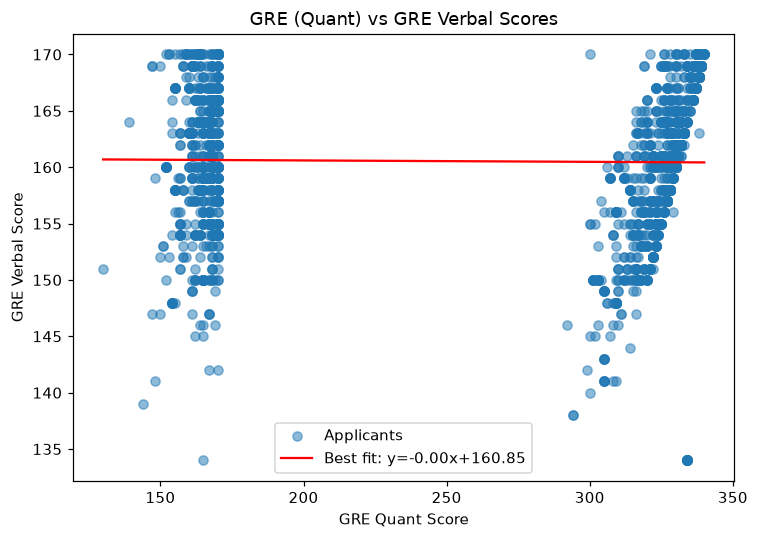

In [26]:
mask = (df["GRE"] > 0) & (df["GRE V"] > 0)
n_points = mask.sum()

fig, ax = plt.subplots(figsize=(7, 5))

if n_points >= 2:
    x, y = df.loc[mask, "GRE"], df.loc[mask, "GRE V"]
    ax.scatter(x, y, alpha=0.5, label="Applicants")
    coeffs = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, np.polyval(coeffs, x_line), color="red",
            label=f"Best fit: y={coeffs[0]:.2f}x+{coeffs[1]:.2f}")
    ax.legend()
else:
    ax.text(0.5, 0.5, f"No overlapping GRE/GRE V data available (n={n_points})\nGRE column contained only invalid values in this dataset",
            ha="center", va="center", transform=ax.transAxes, fontsize=11, wrap=True)

ax.set_title("GRE (Quant) vs GRE Verbal Scores")
ax.set_xlabel("GRE Quant Score")
ax.set_ylabel("GRE Verbal Score")
fig.tight_layout()
fig.savefig("GRE-vs-GRE-V.png")
plt.show()

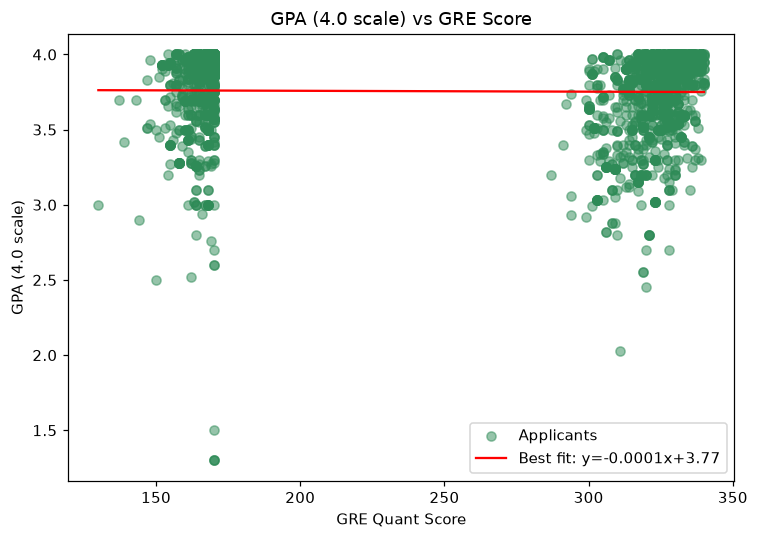

In [27]:
mask = (df["has_valid_gpa"] == 1) & (df["GRE"] > 0)
n_points = mask.sum()

fig, ax = plt.subplots(figsize=(7, 5))

if n_points >= 2:
    x, y = df.loc[mask, "GRE"], df.loc[mask, "GPA"]
    ax.scatter(x, y, alpha=0.5, color="seagreen", label="Applicants")
    coeffs = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, np.polyval(coeffs, x_line), color="red",
            label=f"Best fit: y={coeffs[0]:.4f}x+{coeffs[1]:.2f}")
    ax.legend()
else:
    ax.text(0.5, 0.5, f"No valid GPA/GRE pairs available (n={n_points})\nGRE column contained only invalid values in this dataset",
            ha="center", va="center", transform=ax.transAxes, fontsize=11, wrap=True)

ax.set_title("GPA (4.0 scale) vs GRE Score")
ax.set_xlabel("GRE Quant Score")
ax.set_ylabel("GPA (4.0 scale)")
fig.tight_layout()
fig.savefig("GPA-vs-GRE.png")
plt.show()

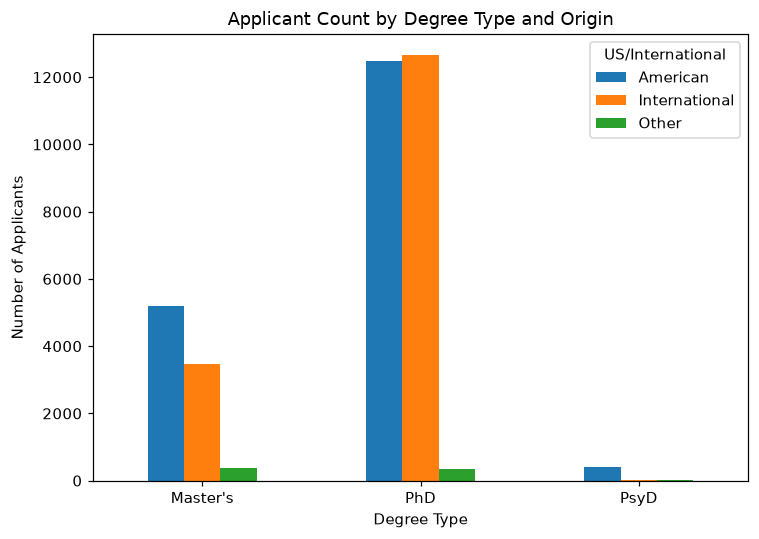

In [28]:
degree_intl = pd.crosstab(df["Degree"], df["US/International"])

fig, ax = plt.subplots(figsize=(7, 5))
degree_intl.plot(kind="bar", ax=ax)
ax.set_title("Applicant Count by Degree Type and Origin")
ax.set_xlabel("Degree Type")
ax.set_ylabel("Number of Applicants")
ax.legend(title="US/International")
plt.xticks(rotation=0)
fig.tight_layout()
fig.savefig("Degree-vs-International.png")
plt.show()

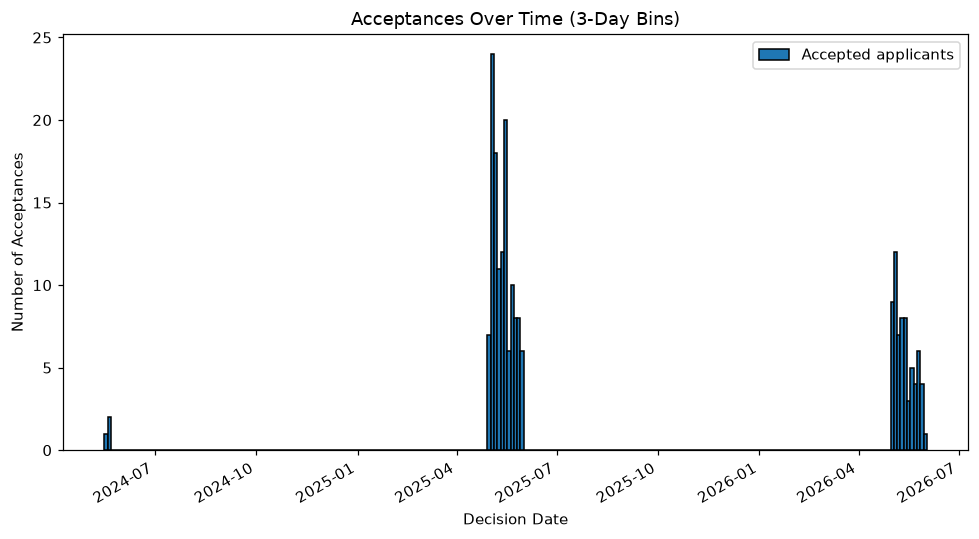

In [29]:
accepted = df.loc[(df["outcome"] == "Accepted") & df["decision_date"].notna()]

date_min, date_max = accepted["decision_date"].min(), accepted["decision_date"].max()
bin_edges = pd.date_range(date_min, date_max + pd.Timedelta(days=3), freq="3D")

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(accepted["decision_date"], bins=bin_edges, edgecolor="black", label="Accepted applicants")
ax.set_title("Acceptances Over Time (3-Day Bins)")
ax.set_xlabel("Decision Date")
ax.set_ylabel("Number of Acceptances")
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig("Acceptances-over-Time.png")
plt.show()

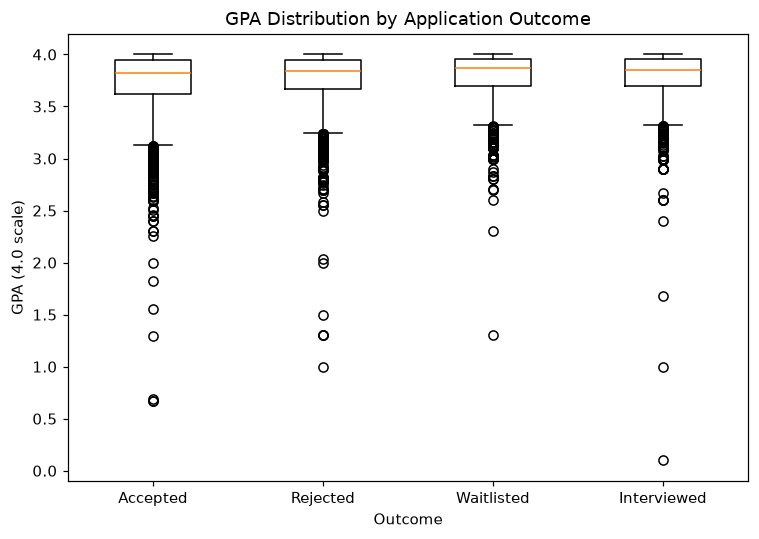

In [30]:
outcome_order = [o for o in ["Accepted", "Rejected", "Waitlisted", "Interviewed"] if o in df["outcome"].unique()]
data_by_outcome = [df.loc[(df["outcome"] == o) & (df["has_valid_gpa"] == 1), "GPA"] for o in outcome_order]

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot(data_by_outcome, tick_labels=outcome_order)
ax.set_title("GPA Distribution by Application Outcome")
ax.set_xlabel("Outcome")
ax.set_ylabel("GPA (4.0 scale)")
fig.tight_layout()
fig.savefig("GPA-by-Outcome.png")
plt.show()


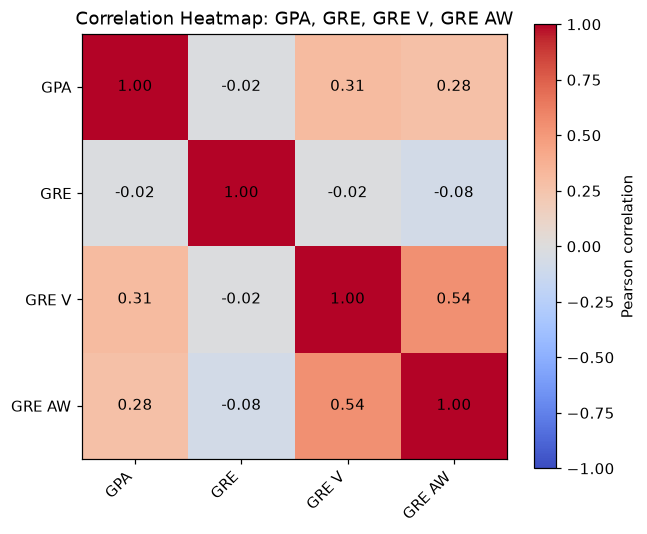

In [31]:
corr_matrix = df[["GPA", "GRE", "GRE V", "GRE AW"]].corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_matrix.columns)

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        val = corr_matrix.iloc[i, j]
        label = f"{val:.2f}" if pd.notna(val) else "N/A"
        ax.text(j, i, label, ha="center", va="center", color="black")

ax.set_title("Correlation Heatmap: GPA, GRE, GRE V, GRE AW")
fig.colorbar(im, ax=ax, label="Pearson correlation")
fig.tight_layout()
fig.savefig("Numeric-Correlation-Heatmap.png")
plt.show()

## 8. Analytical Summary (`analytics.pdf`)

In [32]:
from reportlab.lib.pagesizes import letter
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import inch

# --- Recompute the stats this summary depends on, using the cleaned data ---

accepted_phd_gre = df.loc[
    (df["outcome"] == "Accepted") & (df["Degree"] == "PhD") & df["GRE"].notna(),
    "GRE"
]
avg_gre_accepted_phd = accepted_phd_gre.mean()
n_accepted_phd_gre = len(accepted_phd_gre)

accepted_masters_gpa = df.loc[
    (df["outcome"] == "Accepted") & (df["Degree"] == "Master's") & df["has_valid_gpa"] == 1,
    "GPA"
]
avg_gpa_accepted_masters = accepted_masters_gpa.mean()
n_accepted_masters_gpa = len(accepted_masters_gpa)

def describe_correlation(r):
    if pd.isna(r):
        return "could not be computed (insufficient paired data)"
    strength = "weak" if abs(r) < 0.3 else "moderate" if abs(r) < 0.6 else "strong"
    direction = "positive" if r > 0 else "negative"
    return f"a {strength} {direction} relationship (r = {r:.3f})"

gpa_gre_relationship = describe_correlation(gpa_gre_r)

gpa_diff_direction = "different" if not pd.isna(group_p) and group_p < 0.05 else "similar"
gpa_significance = "was" if not pd.isna(group_p) and group_p < 0.05 else "was not"

chi2_significance = "was" if not pd.isna(chi2_p) and chi2_p < 0.05 else "was not"

summary_sections = [
    ("1. Average GRE score of accepted PhD applicants",
     f"The average GRE score of accepted PhD applicants was "
     f"{'N/A (no valid GRE scores among accepted PhD applicants in this dataset)' if pd.isna(avg_gre_accepted_phd) else f'{avg_gre_accepted_phd:.1f}'} "
     f"based on {n_accepted_phd_gre} applicants with available GRE scores."),

    ("2. Average GPA of accepted Master's applicants",
     f"The average GPA of accepted Master's applicants was {avg_gpa_accepted_masters:.2f} "
     f"based on {n_accepted_masters_gpa} applicants with valid GPA values."),

    ("3. Shortcomings of inferring decision_date",
     "Inferring decision dates from status text can be inaccurate because entries are "
     "user-written and may contain missing or inconsistent dates. The term value can also "
     "cause incorrect year assignments when decisions are posted outside the expected "
     f"timeline. {n_invalid_days} rows had a computed days_to_decision that was negative or "
     "unrealistically large (over 365 days) and were excluded from downstream analysis."),

    ("4. Correlation analysis",
     f"The correlation analysis showed that GPA and GRE scores had {gpa_gre_relationship}. "
     f"This suggests academic performance and GRE scores are related to some degree, but "
     f"one measure cannot reliably predict the other on its own."),

    ("5. Accepted vs rejected GPA comparison",
     f"Accepted (mean GPA = {accepted_gpa.mean():.3f}, n={len(accepted_gpa)}) and rejected "
     f"(mean GPA = {rejected_gpa.mean():.3f}, n={len(rejected_gpa)}) applicants had "
     f"{gpa_diff_direction} GPA averages. A Mann-Whitney U test showed that GPA "
     f"{gpa_significance} significantly different between groups "
     f"(U = {group_stat:.1f}, p = {group_p:.4g})."),

    ("6. Chi-square test",
     f"The chi-square test showed that there {chi2_significance} a significant relationship "
     f"between degree type and applicant origin (chi-square = {chi2_stat:.3f}, "
     f"p = {chi2_p:.4g}, dof = {dof})."),

    ("7. Remaining data quality issues",
     "Remaining issues include missing values, inconsistent text fields, possible "
     "duplicates, and self-reported data bias. GPA and GRE AW values of exactly zero were "
     "treated as missing rather than real scores, and GRE values were accepted under either "
     "the modern single-section scale or the older combined scale, since the raw data mixed "
     "both without indicating which was used. These limitations mean the dataset may not "
     "fully represent all graduate applicants."),
]

# --- Build the PDF ---

styles = getSampleStyleSheet()
title_style = ParagraphStyle("TitleStyle", parent=styles["Title"], spaceAfter=20)
heading_style = ParagraphStyle("HeadingStyle", parent=styles["Heading2"], spaceBefore=14, spaceAfter=6)
body_style = ParagraphStyle("BodyStyle", parent=styles["BodyText"], spaceAfter=6, leading=15)

doc = SimpleDocTemplate("analytics.pdf", pagesize=letter,
                         topMargin=0.75 * inch, bottomMargin=0.75 * inch)

story = [Paragraph("Grad Cafe Analytics Summary", title_style)]

for heading, body in summary_sections:
    story.append(Paragraph(heading, heading_style))
    story.append(Paragraph(body, body_style))

doc.build(story)

print("Saved analytics.pdf with computed values (no placeholders).")
for heading, body in summary_sections:
    print(f"\n{heading}")
    print(body)


Saved analytics.pdf with computed values (no placeholders).

1. Average GRE score of accepted PhD applicants
The average GRE score of accepted PhD applicants was 266.8 based on 608 applicants with available GRE scores.

2. Average GPA of accepted Master's applicants
The average GPA of accepted Master's applicants was 3.70 based on 4598 applicants with valid GPA values.

3. Shortcomings of inferring decision_date
Inferring decision dates from status text can be inaccurate because entries are user-written and may contain missing or inconsistent dates. The term value can also cause incorrect year assignments when decisions are posted outside the expected timeline. 168 rows had a computed days_to_decision that was negative or unrealistically large (over 365 days) and were excluded from downstream analysis.

4. Correlation analysis
The correlation analysis showed that GPA and GRE scores had a weak negative relationship (r = -0.016). This suggests academic performance and GRE scores are rela

## 9. Save Cleaned Dataset and Return It to S3

In [33]:
cleaned_records = json.loads(df.to_json(orient="records", date_format="iso"))
with open("cleaned_gradcafe.json", "w") as f:
    json.dump(cleaned_records, f, indent=2)

print(f"Saved cleaned_gradcafe.json ({len(df)} rows)")

Saved cleaned_gradcafe.json (34990 rows)


In [34]:
BUCKET_NAME = "grad-cafe-rps"
CLEANED_KEY = "cleaned_gradcafe.json"

s3_client.upload_file(
    "cleaned_gradcafe.json",
    BUCKET_NAME,
    CLEANED_KEY
)

print(f"Upload succeeded: cleaned_gradcafe.json uploaded to s3://{BUCKET_NAME}/{CLEANED_KEY}")

NameError: name 's3_client' is not defined